In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [2]:
df = pd.read_excel("arjun.xlsx.xlsx")
df

,ORDER ID,BRAND,MONTH,Region,STATE,CITY,QTY,AMT
0,1001,NIKE,Apr,South,ANDHRA PRADESH,VIJAYWADA,72.0,54720.0
1,1002,NIKE,Apr,NaN,ASSAM,DHUBRI,120.0,80320.0
2,1003,NIKE,Apr,East,BIHAR,PATNA JUNCTION,379.0,217685.0
3,1004,NIKE,Apr,East,BIHAR,PATNA JUNCTION,213.0,119055.0
4,1005,NIKE,Apr,East,BIHAR,MUJAFARPUR,72.0,54720.0
...,...,...,...,...,...,...,...,...
28598,29599,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,52.0,35350.0
28599,29600,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,57.0,30685.0
28600,29601,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,84.0,42430.0
28601,29602,REEBOK,Dec,North,Uttaranchal,KHATIMA,144.0,75600.0


In [5]:
print(df.index[df["Region"].isna()])

Index([    1,    12,    23,    24,    59,    66,    67,    68,    69,    70,
       ...
       27680, 27996, 27997, 27998, 27999, 28000, 28001, 28344, 28345, 28415],
      dtype='int64', length=1231)


In [6]:
df["Region"]=df["Region"].fillna("South")

In [7]:
print(df.index[df["Region"].isna()])

Index([], dtype='int64')


In [8]:
len(df)

28603

In [9]:
df.isnull().sum()

ORDER ID    0
BRAND       0
MONTH       0
Region      0
STATE       0
CITY        0
QTY         0
AMT         0
dtype: int64

In [10]:
df


,ORDER ID,BRAND,MONTH,Region,STATE,CITY,QTY,AMT
0,1001,NIKE,Apr,South,ANDHRA PRADESH,VIJAYWADA,72.0,54720.0
1,1002,NIKE,Apr,South,ASSAM,DHUBRI,120.0,80320.0
2,1003,NIKE,Apr,East,BIHAR,PATNA JUNCTION,379.0,217685.0
3,1004,NIKE,Apr,East,BIHAR,PATNA JUNCTION,213.0,119055.0
4,1005,NIKE,Apr,East,BIHAR,MUJAFARPUR,72.0,54720.0
...,...,...,...,...,...,...,...,...
28598,29599,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,52.0,35350.0
28599,29600,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,57.0,30685.0
28600,29601,REEBOK,Dec,South,TAMIL NADU,COIMBATOR,84.0,42430.0
28601,29602,REEBOK,Dec,North,Uttaranchal,KHATIMA,144.0,75600.0


In [11]:
print(df.describe())

           ORDER ID           QTY           AMT
count  28603.000000  28603.000000  2.860300e+04
mean   15302.000000    113.787042  5.997723e+04
std     8257.119211    193.353722  7.922027e+04
min     1001.000000      0.000000  0.000000e+00
25%     8151.500000     52.000000  2.677500e+04
50%    15302.000000     71.000000  3.696500e+04
75%    22452.500000    123.000000  6.419750e+04
max    29603.000000   9957.000000  3.146840e+06


In [12]:
highest = df.sort_values(by = ["MONTH"], ascending = False)
print(highest["AMT"])

24170     40795.0
7235      32855.0
7259      29380.0
7260      16215.0
7261      23370.0
           ...   
16949     33842.0
16948     86264.0
16947     26544.0
16946    132303.0
0         54720.0
Name: AMT, Length: 28603, dtype: float64


In [49]:
total = np.array(df.head(10)["QTY"]) * np.array(df.head(10)["AMT"])
print(total)

[ 3939840.  9638400. 82502615. 25358715.  3939840. 25358715.  2466700.
 56421530. 15759360.  2526235.]


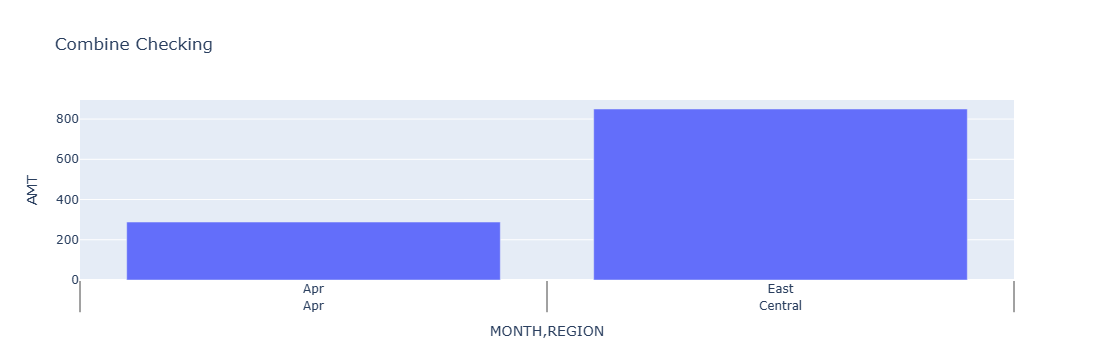

In [12]:

counts = df.groupby(["MONTH","Region"])["AMT"].count().head(100)
fig = go.Figure(
    go.Bar(
        x=counts.index,
        y=counts.values
    )
)

fig.update_layout(
    title="Combine Checking ",
    xaxis_title="MONTH,REGION",
    yaxis_title="AMT"
)

fig.show()

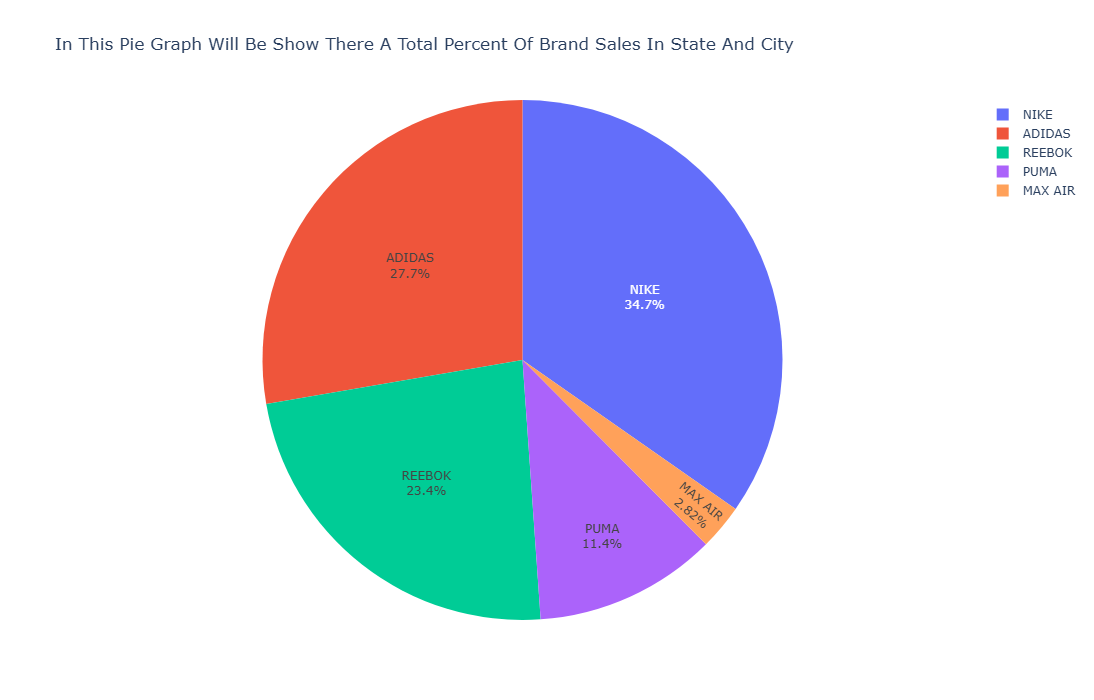

In [50]:
counts = df.groupby(["BRAND", "STATE", "CITY"])["AMT"].sum().reset_index()

fig = go.Figure(
    go.Pie(
        labels=counts["BRAND"],
        values=counts["AMT"],
        text=counts["STATE"] + " - " + counts["CITY"],
        textinfo="label+percent"
    ))

fig.update_layout(
    title="In This Pie Graph Will Be Show There A Total Percent Of Brand Sales In State And City",
    width = 700,
    height = 700
)

fig.show()

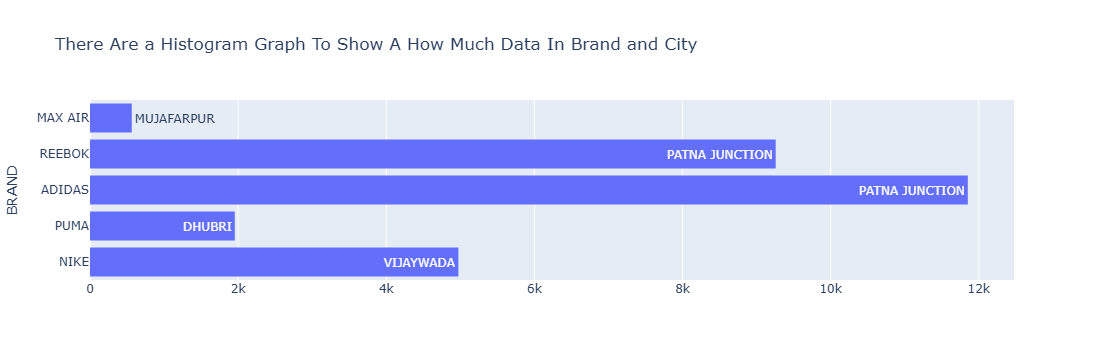

In [13]:
fig = go.Figure()

fig.add_trace(go.Histogram( y = df["BRAND"],text=df["CITY"]
                          ))

fig.update_layout( title = "There Are a Histogram Graph To Show A How Much Data In Brand and City",
                    yaxis_title = "BRAND"
                  )
fig.show()
              

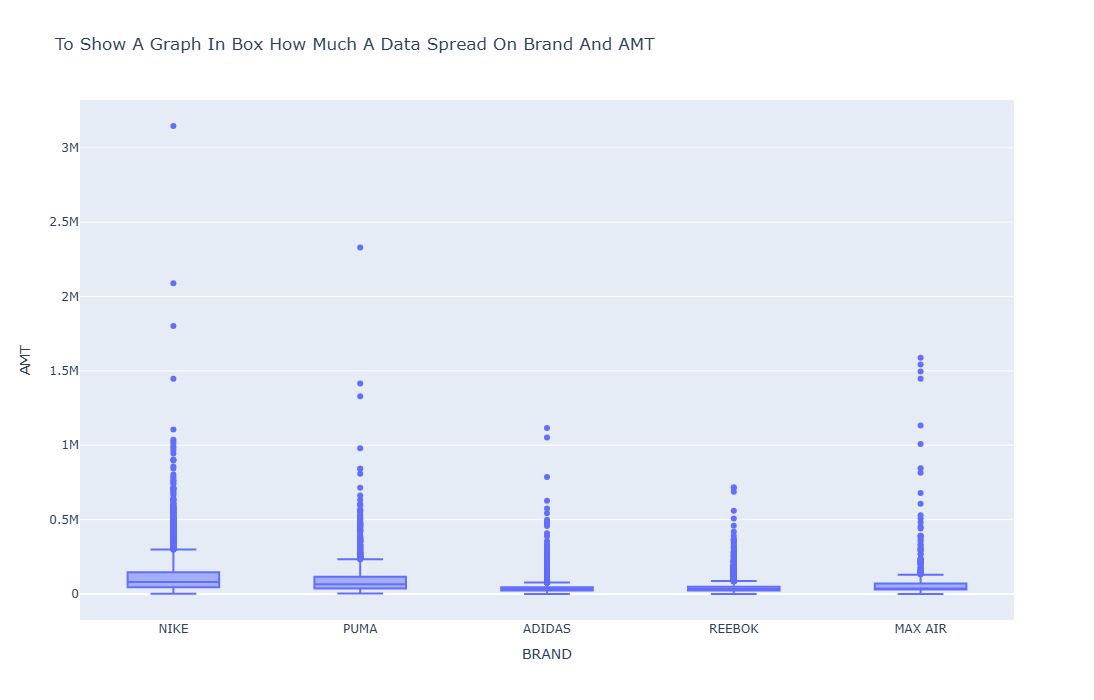

In [32]:
fig = go.Figure()
 
fig.add_trace(go.Box(x = df["BRAND"], y =df["AMT"], hovertemplate = "BRAND %{x}<br>+ AMT:%{y} <br>+ <extra></extra>"
))

fig.update_layout( title = " To Show A Graph In Box How Much A Data Spread On Brand And AMT",
                   xaxis_title = "BRAND",
                   yaxis_title = "AMT",
                   height = 700,
                   width = 700
                 )
fig.show()


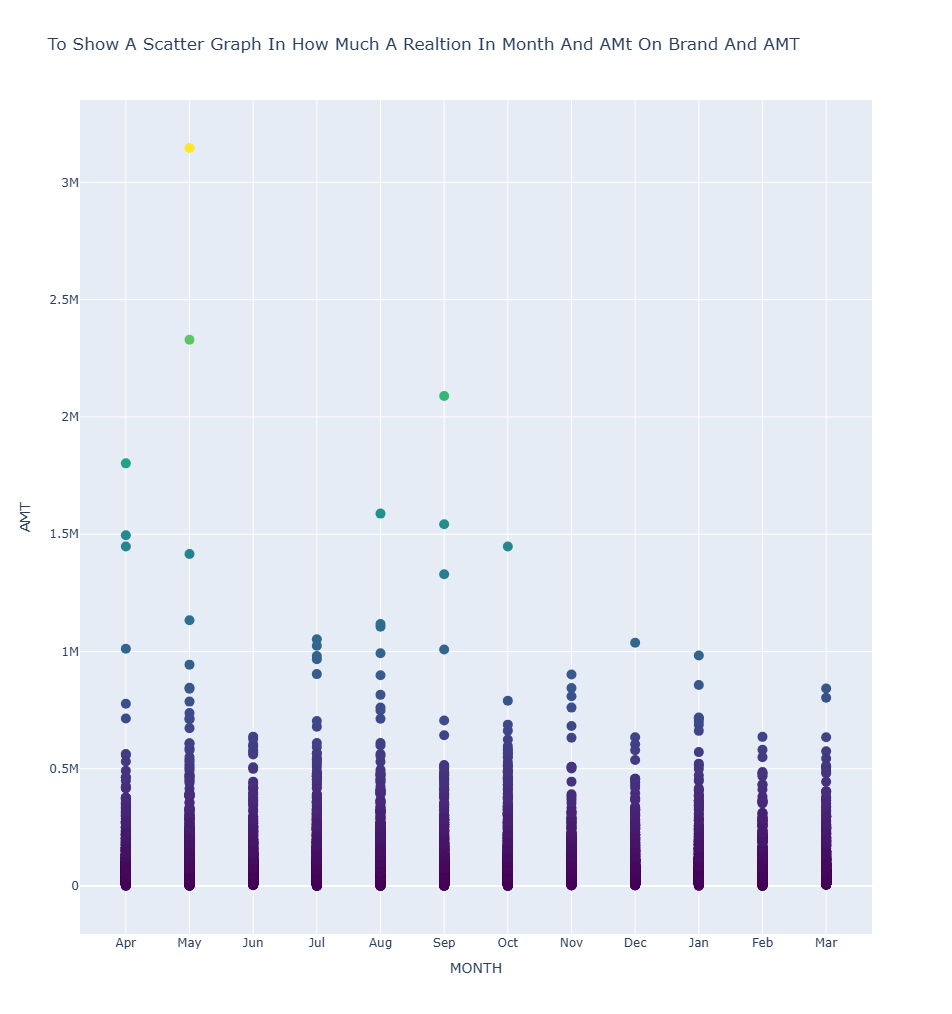

In [21]:
fig= go.Figure()
fig.add_trace(go.Scatter( x = df["MONTH"], y =df["AMT"],mode = "markers", marker = dict(size = 10,color = df["AMT"],colorscale ="viridis")
                        ))

fig.update_layout( title = " To Show A Scatter Graph In How Much A Realtion In Month And AMt On Brand And AMT",
                   xaxis_title = "MONTH",
                   yaxis_title = "AMT",
                   height = 1000,
                   width = 1000
                 )
fig.show()

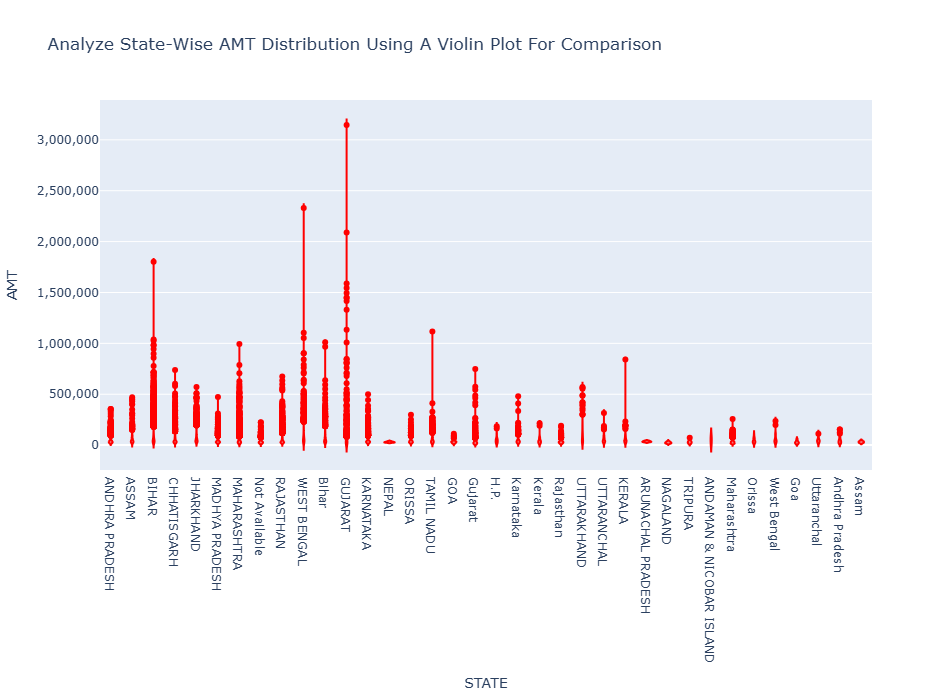

In [48]:
fig = go.Figure()

fig.add_trace(go.Violin(x = df["STATE"], y=df["AMT"],marker_color = "red"
                       ))
fig.update_layout( title = "Analyze State-Wise AMT Distribution Using A Violin Plot For Comparison",
                   xaxis_title = "STATE",
                   yaxis_title = "AMT",
                   yaxis_tickformat=(","),
                   height = 700
                 )
fig.show()